In [1]:
#Initial scraping of data from spotrac

import requests
import csv
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
from bs4 import BeautifulSoup
from csv import writer
from statsmodels.formula.api import ols, logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


# Web Scraping

The following cells of code are used to scrape online data. As this process can be time intensive, this code is only intended to be run once. Once the data has been scraped, it is saved to csv files so that the data can be cleaned and analyzed at a later date without having to re-scrape (done in the second section of this notebook).

The first website scraped is pro-football-reference.com. This pulls the end of season records for every team.

In [131]:
#function to scrape end of season records from pro-football-reference
def get_yearly_results(year):
    '''Function to scrape pro-football-reference for the end of season records of all NFL teams
    Variables: year - integer
    Returns: DataFrame of end of season records
    '''

    url = "https://www.pro-football-reference.com/years/{}/".format(year)
    season_records = requests.get(url).text
    season_soup = BeautifulSoup(season_records,"html.parser")

    conference_tables = season_soup.find_all('tbody')

    all_rows = []
    column_names = ['Team', 'Win', 'Loss', 'Tie', 'Win_Loss', 'Points_For', 'Points_Allowed', 
                    'Point_Differential', 'Margin_of_Victory', 'Strength_of_Schedule', 'SRS',
                    'Off_SRS', 'Def_SRS']
    for c in conference_tables:
        rows = c.find_all('tr')
        for r in rows:
            elements = r.find_all(['td','th'])
            element_list = []
            for e in elements:
                element_list.append(e.text)
            if len(element_list) > 1:
                if len(element_list) < len(column_names):
                    #Some years don't have ties, and the column is left off.
                    #Add in a tie column if not present
                    element_list.insert(3, '0')
                all_rows.append(element_list)

    year_results_df = pd.DataFrame(all_rows, columns = column_names)
    #remove special characters from team names which indicate playoff positions
    year_results_df['Team'] = [team if team[-1].isalpha() else team[:-1] for team in year_results_df['Team']]
    year_results_df['Year'] = [year for i in year_results_df['Team']]

    #set appropriate data types for each column
    ints = ['Win', 'Loss', 'Tie', 'Points_For', 'Points_Allowed', 'Point_Differential']
    floats = ['Win_Loss', 'Margin_of_Victory', 'Strength_of_Schedule', 'SRS', 'Off_SRS', 'Def_SRS']
    year_results_df[ints] = year_results_df[ints].astype('int')
    year_results_df[floats] = year_results_df[floats].astype('float')

    return year_results_df

In [20]:
years = np.arange(2014, 2024)

#get all end of season results for every year

dataframes = []

for y in years:

    results = get_yearly_results(y)
    dataframes.append(results)

yearly_results = pd.concat(dataframes)
yearly_results = yearly_results.reset_index(drop = True)


#Note that in the time period in question, there have been several team name changes.

#Oakland Raiders (-2019) to Las Vegas Raiders (2020-)
#San Diego Chargers (-2016) to Los Angeles Chargers (2017-)
#St. Louis Rams (-2015) to Los Angeles Rams (2016-)
#Washington Redskins (-2019) to Washington Football Team (2020-2021) to Washington Commanders (2022-)

#The other two datasets use the present team name, so for the purposes of joining tables, 
#these names will be converted here


def curr_team_name(team):
    if team == 'Oakland Raiders':
        team = 'Las Vegas Raiders'
    elif team == 'San Diego Chargers':
        team = 'Los Angeles Chargers'
    elif team == 'St. Louis Rams':
        team = 'Los Angeles Rams'
    elif team == 'Washington Redskins' or team == 'Washington Football Team':
        team = 'Washington Commanders'
    return team

yearly_results['Team'] = [curr_team_name(team) for team in yearly_results['Team']]
yearly_results
yearly_results.to_csv('yearly_results.csv', index = False)

yearly_results.head()

,Team,Win,Loss,Tie,Win_Loss,Points_For,Points_Allowed,Point_Differential,Margin_of_Victory,Strength_of_Schedule,SRS,Off_SRS,Def_SRS,Year
0,New England Patriots,12,4,0,0.750,468,313,155,9.7,1.3,10.9,7.5,3.5,2014
1,Buffalo Bills,9,7,0,0.563,343,289,54,3.4,1.6,4.9,-0.4,5.3,2014
2,Miami Dolphins,8,8,0,0.500,388,373,15,0.9,1.6,2.6,2.9,-0.4,2014
3,New York Jets,4,12,0,0.250,283,401,-118,-7.4,2.3,-5.0,-4.0,-1.0,2014
4,Pittsburgh Steelers,11,5,0,0.688,436,368,68,4.3,-2.0,2.2,4.4,-2.1,2014


The second website scraped is spotrac.com. This pulls cap data for every NFL team for every year analyzed (2014-2023).

In [170]:
#load yearly results from csv to avoid running the above cell if preferred
yearly_results = pd.read_csv('yearly_results.csv')

#define a function to scrape spotrac.com for all cap data for an NFL team for a certain year
def get_pos_breakdown(team, year):
    url = "https://www.spotrac.com/nfl/{0}/cap/_/year/{1}/sort/cap_total".format(team, year)

    response = requests.get(url).text
    #pass contents of website using bs and convert to txt
    soup = BeautifulSoup(response,"html.parser")

    tables = soup.find_all('table')

    bodies = []
    for t in tables:
        head = t.find_all('thead')
        if len(head) > 0:
            cols = head[0].find_all('th')
            col_names = []
            for c in cols:
                name = re.sub('[^a-zA-Z]', ' ', c.text).strip()
                col_names.append(name)
            
        body = t.find_all('tbody')
        rows = body[0].find_all('tr')
        all_rows = []
        for r in rows:
            elements = r.find_all(['td','th'])
            element_list = []
            for e in elements:
                element_list.append(e.text.strip())
            all_rows.append(element_list)
        try:
            df = pd.DataFrame(all_rows, columns = col_names)
        except:
            df = pd.DataFrame(all_rows)
        bodies.append(df)

    all_players = pd.DataFrame(columns = ['Player', 'Pos', 'Cap Hit'])
    for df in bodies:
        try:
            data = df[['Player', 'Pos', 'Cap Hit']]
            all_players = pd.concat([all_players, data])
        except:
            None

    all_players['Cap Hit'] = [re.sub('[^\d]', '', amount) for amount in all_players['Cap Hit']]
    #if no data given for a player, assume the contribution is zero
    all_players['Cap Hit'] = [0 if amount == '' else amount for amount in all_players['Cap Hit']]
    all_players['Cap Hit'] = all_players['Cap Hit'].astype('int')
    all_players.reset_index(inplace = True, drop = True)

    pos_breakdown = all_players.groupby('Pos')['Cap Hit'].sum()
    keys = pos_breakdown.index.values
    values = pos_breakdown.values
    pos_dict = dict(zip(keys, values))

    return pos_dict
            

In [8]:
#scape position cap data for each team per year

position_array = []
error_array = []
for i in range(len(yearly_results)):
    team = yearly_results.iloc[i]['Team']
    team = re.sub(' ', '-', team).lower()
    year = str(yearly_results.iloc[i]['Year'])

    try:

        position_results = get_pos_breakdown(team, year)
        position_array.append([team, year, position_results])

    except:
        print('Scraping error for {0} {1}.'.format(year, team))
        error_array.append([team, year])

Scraping error for 2021 miami-dolphins.
Scraping error for 2021 los-angeles-chargers.


In [59]:
#create a set of all possible position labels
pos_set = set()
for i in range(len(position_array)):
    pos_dict = position_array[i][2]
    pos_keys = list(pos_dict.keys())
    pos_set.update(pos_keys)

#save all scraped position data to a dataframe, and export to a csv for later use
position_df = pd.DataFrame()
for i in range(len(position_array)):
    pos_dict = position_array[i][2]
    dict_keys = list(pos_dict.keys())
    for p in pos_set:
        if p not in dict_keys:
            pos_dict[p] = 0
    pos_dict['Team'] = position_array[i][0]
    pos_dict['Year'] = position_array[i][1]
    pos_df = pd.DataFrame([pos_dict])
    position_df = pd.concat([pos_df, position_df], ignore_index = True)

position_df = position_df.reset_index(drop = True)
position_df.to_csv('position_breakdown.csv', index = False)

The third section of code scrapes data from quirkyresearch.com. This data gives a timeline of quarterback changes for each NFL team.

In [63]:
#code to scrape injury history of starting quarterbacks from quirkyresearch.com
#each table is labeled with an asterisk when a backup quarterback is replaced by the starter returning
#this code will compile each instance of the returner starter leaving (for whatever reason)
#and determine when they left, and how many games they missed
#Once run, this code will be saved to a csv file so the data will be saved for future use
divisions = ['afc-east', 'afc-north', 'afc-west', 'afc-south',
             'nfc-east', 'nfc-north', 'nfc-west', 'nfc-south']

teams = {'afc-east':['Buffalo Bills', 'Miami Dolphins', 'New England Patriots', 'New York Jets'],
         'afc-north':['Baltimore Ravens', 'Cincinatti Bengals','Cleveland Browns', 'Pittsburgh Steelers'],
         'afc-west':['Denver Broncos', 'Kansas City Chiefs', 'Las Vegas Raiders', 'Los Angeles Chargers'],
         'afc-south':['Houston Texans', 'Indianapolis Colts','Jacksonville Jaguars', 'Tennessee Titans'],
         'nfc-east':['Dallas Cowboys', 'New York Giants', 'Philadelphia Eagles','Washington Commanders'],
         'nfc-north':['Chicago Bears','Detroit Lions','Green Bay Packers','Minnesota Vikings'],
         'nfc-west':['Arizona Cardinals','Los Angeles Rams','San Francisco 49ers','Seattle Seahawks'],
         'nfc-south':['Atlanta Falcons', 'Carolina Panthers', 'New Orleans Saints','Tampa Bay Buccaneers']}

def division_qb_changes(division):
    url = "https://www.quirkyresearch.com/nfl-starting-quarterback-timelines/{}-starting-quarterback-changes/".format(division)

    response = requests.get(url).text


    soup = BeautifulSoup(response,"html.parser")

    tables = soup.find_all('table')
    div_teams = teams[division]
    dfs = []
    for i in range(len(tables)):
        team = div_teams[i]
        table = tables[i]

        rows = table.find_all('tr')
        start_qb_arr = []
        for r in rows:
            vals = r.find_all('td')
            vals = [v.text.strip() for v in vals]
            if len(vals) == 7:
                start_qb_arr.append(vals)
        
        #quarterback log dataframe
        df = pd.DataFrame(start_qb_arr[1:], columns = start_qb_arr[0])
        df['Starting QB'] = [re.sub('\d', '', qb).strip() for qb in df['Starting QB']]

        injury_log = []

        for j in range(len(df)):
            if df.iloc[j]['*'] == '*':
                #if this value is an asterisk, the usual starter returned the next week
                return_starter = df.iloc[j+1]['Starting QB']

                index = j
                qb = df.iloc[index]['Starting QB']
                weeks_missed = 0
                #find when the usual starter left
                while return_starter not in qb:
                    weeks_missed += int(df.iloc[index]['GS'])
                    index -= 1
                    qb = df.iloc[index]['Starting QB']

                reason = df.iloc[index]['Reason for Change From']
                week_injured = df.iloc[index]['Last Start']
                week_returned = df.iloc[j+1]['First Start']
                year = int(week_injured[:4])
                if year > 2013:
                    report = [qb, team, year, weeks_missed, reason]
                    injury_log.append(report)

        injury_df = pd.DataFrame(injury_log, columns = ['Quarterback', 'Team', 'Year', 'Games_Missed', 'Reason'])
        dfs.append(injury_df)
    return(pd.concat(dfs))

injury_dfs = []
for d in divisions:
    injury_df = division_qb_changes(d)
    injury_dfs.append(injury_df)
all_injuries = pd.concat(injury_dfs)

all_injuries.to_csv('all_injuries.csv')
#once saved to a csv file, I will copy the csv into excel and label each instance by hand
#as to whether or not the reason the quarterback left was due to a football injury

# Clean and combine data

This section of code performs any additional cleaning needed on the data, and merges all three datasets into one dataframe for analysis. As all the scraped data has been saved to csv files at this point, the previous section of cells do not have to be run in order for this code to work. This code does not require any web scraping, and as such should run relatively fast.

In [148]:
#load yearly results from csv
yearly_results = pd.read_csv('yearly_results.csv')

In [149]:
#notes on cleaning all_injuries file
#An extra entry for Deshawn Watson was created for the Cleveland Browns as he returned from 
#suspension, but had never started a game for the Browns at that point. As the code assumes
#a quarterback has started before they return, this created a ficticious entry which was deleted.

#import hand cleaned data
all_injuries_labeled = pd.read_csv('all_injuries_labeled.csv')
all_injuries_filtered = all_injuries_labeled[all_injuries_labeled['Injured'] == 1][['Team', 'Year', 'Games_Missed']]
all_injuries_filtered

injuries_summed = all_injuries_filtered.groupby(['Year', 'Team']).sum('Games_Missed')
injuries_summed.reset_index(inplace = True)
injuries_summed

yr_copy = yearly_results.copy()

yearly_and_injuries = pd.merge(yr_copy, injuries_summed, on = ['Team', 'Year'], how = 'left')
yearly_and_injuries['Games_Missed'] = yearly_and_injuries['Games_Missed'].fillna(0).astype('int')
yearly_and_injuries.head()

,Team,Win,Loss,Tie,Win_Loss,Points_For,Points_Allowed,Point_Differential,Margin_of_Victory,Strength_of_Schedule,SRS,Off_SRS,Def_SRS,Year,Games_Missed
0,New England Patriots,12,4,0,0.750,468,313,155,9.7,1.3,10.9,7.5,3.5,2014,0
1,Buffalo Bills,9,7,0,0.563,343,289,54,3.4,1.6,4.9,-0.4,5.3,2014,0
2,Miami Dolphins,8,8,0,0.500,388,373,15,0.9,1.6,2.6,2.9,-0.4,2014,0
3,New York Jets,4,12,0,0.250,283,401,-118,-7.4,2.3,-5.0,-4.0,-1.0,2014,0
4,Pittsburgh Steelers,11,5,0,0.688,436,368,68,4.3,-2.0,2.2,4.4,-2.1,2014,0


In [150]:
position_breakdown = pd.read_csv('position_breakdown.csv')

def clean_team_name(name):
    cleaned = re.sub('-', ' ', name)
    cleaned = ' '.join(w.capitalize() for w in cleaned.split())
    
    return cleaned

position_breakdown['Team'] = [clean_team_name(team) for team in position_breakdown['Team']]

#represent each positional spending as a fraction of the team's total spending for the year
pos_columns = position_breakdown.columns[:-2]
tot_spending = position_breakdown[pos_columns].sum(axis = 1)
position_breakdown['Tot_Spending'] = tot_spending

for col in pos_columns:
    position_breakdown[col] = position_breakdown[col]/position_breakdown['Tot_Spending']

position_breakdown.drop(columns='Tot_Spending',inplace = True)

all_data = pd.merge(yearly_and_injuries, position_breakdown, on = ['Team', 'Year'], how = 'left')

#two data points could not be scraped from spotrac: 2021 Miami Dolphins and 2021 LA Chargers
#visiting the actual website shows the website timing out - there must be a site issue
#as this only accounts for 0.6% of the data, I will simply drop these two rows
all_data.dropna(inplace = True)
all_data.reset_index(drop = True, inplace = True)

#sum of all positions on the offensive line
o_line = ['C','G','LT','RT','T','OL']
all_data['O_Line'] = all_data[o_line].sum(axis = 1)

all_data.to_csv('nfl_data.csv', index = False)
all_data.head()

,Team,Win,Loss,Tie,Win_Loss,Points_For,Points_Allowed,Point_Differential,Margin_of_Victory,Strength_of_Schedule,SRS,Off_SRS,Def_SRS,Year,Games_Missed,C,CB,DE,DT,FS,G,ILB,K,LB,LS,LT,OLB,P,QB,RB,RT,S,SS,T,TE,WR,OL,FB,WLB,KR,O_Line
0,New England Patriots,12,4,0,0.750,468,313,155,9.7,1.3,10.9,7.5,3.5,2014,0,0.016125,0.116874,0.008122,0.094889,0.045105,0.070942,0.062511,0.028290,0.0,0.005591,0.020231,0.074949,0.003689,0.116238,0.030002,0.044146,0.012076,0.022000,0.003723,0.113084,0.107095,0.0,0.004318,0.0,0.0,0.155167
1,Buffalo Bills,9,7,0,0.563,343,289,54,3.4,1.6,4.9,-0.4,5.3,2014,0,0.041327,0.067744,0.176563,0.099448,0.024227,0.043619,0.034099,0.024617,0.0,0.008357,0.014056,0.055851,0.002844,0.092279,0.078387,0.032883,0.000736,0.042160,0.000000,0.023052,0.134329,0.0,0.003424,0.0,0.0,0.131885
2,Miami Dolphins,8,8,0,0.500,388,373,15,0.9,1.6,2.6,2.9,-0.4,2014,0,0.034942,0.085551,0.145261,0.032730,0.032240,0.042751,0.031934,0.003728,0.0,0.006845,0.030012,0.133518,0.025173,0.063276,0.039899,0.034531,0.000049,0.032885,0.000035,0.021591,0.203025,0.0,0.000023,0.0,0.0,0.142272
3,New York Jets,4,12,0,0.250,283,401,-118,-7.4,2.3,-5.0,-4.0,-1.0,2014,0,0.066941,0.131489,0.036448,0.043119,0.019217,0.031767,0.078759,0.030420,0.0,0.006718,0.098863,0.064057,0.004183,0.086943,0.053323,0.030017,0.015421,0.002203,0.000000,0.028893,0.164254,0.0,0.006964,0.0,0.0,0.227589
4,Pittsburgh Steelers,11,5,0,0.688,436,368,68,4.3,-2.0,2.2,4.4,-2.1,2014,0,0.046086,0.102619,0.034267,0.038365,0.021245,0.066095,0.123676,0.013358,0.0,0.004820,0.014850,0.141008,0.003196,0.161691,0.023410,0.021393,0.049221,0.012309,0.000000,0.059695,0.058376,0.0,0.004320,0.0,0.0,0.148424


# Data Analysis

As in the previous sections, this section is designed to be able to run separately from the others, so this code is not reliant on running the above code. At this point, all the data has been cleaned into one csv file, which is read here.

In [2]:
#import cleaned data
cleaned_data = pd.read_csv('nfl_data.csv')
cleaned_data.set_index(['Team', 'Year'], inplace = True)
cleaned_data.head()

,,Win,Loss,Tie,Win_Loss,Points_For,Points_Allowed,Point_Differential,Margin_of_Victory,Strength_of_Schedule,SRS,Off_SRS,Def_SRS,Games_Missed,C,CB,DE,DT,FS,G,ILB,K,LB,LS,LT,OLB,P,QB,RB,RT,S,SS,T,TE,WR,OL,FB,WLB,KR,O_Line
Team,Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
New England Patriots,2014,12,4,0,0.750,468,313,155,9.7,1.3,10.9,7.5,3.5,0,0.016125,0.116874,0.008122,0.094889,0.045105,0.070942,0.062511,0.028290,0.0,0.005591,0.020231,0.074949,0.003689,0.116238,0.030002,0.044146,0.012076,0.022000,0.003723,0.113084,0.107095,0.0,0.004318,0.0,0.0,0.155167
Buffalo Bills,2014,9,7,0,0.563,343,289,54,3.4,1.6,4.9,-0.4,5.3,0,0.041327,0.067744,0.176563,0.099448,0.024227,0.043619,0.034099,0.024617,0.0,0.008357,0.014056,0.055851,0.002844,0.092279,0.078387,0.032883,0.000736,0.042160,0.000000,0.023052,0.134329,0.0,0.003424,0.0,0.0,0.131885
Miami Dolphins,2014,8,8,0,0.500,388,373,15,0.9,1.6,2.6,2.9,-0.4,0,0.034942,0.085551,0.145261,0.032730,0.032240,0.042751,0.031934,0.003728,0.0,0.006845,0.030012,0.133518,0.025173,0.063276,0.039899,0.034531,0.000049,0.032885,0.000035,0.021591,0.203025,0.0,0.000023,0.0,0.0,0.142272
New York Jets,2014,4,12,0,0.250,283,401,-118,-7.4,2.3,-5.0,-4.0,-1.0,0,0.066941,0.131489,0.036448,0.043119,0.019217,0.031767,0.078759,0.030420,0.0,0.006718,0.098863,0.064057,0.004183,0.086943,0.053323,0.030017,0.015421,0.002203,0.000000,0.028893,0.164254,0.0,0.006964,0.0,0.0,0.227589
Pittsburgh Steelers,2014,11,5,0,0.688,436,368,68,4.3,-2.0,2.2,4.4,-2.1,0,0.046086,0.102619,0.034267,0.038365,0.021245,0.066095,0.123676,0.013358,0.0,0.004820,0.014850,0.141008,0.003196,0.161691,0.023410,0.021393,0.049221,0.012309,0.000000,0.059695,0.058376,0.0,0.004320,0.0,0.0,0.148424


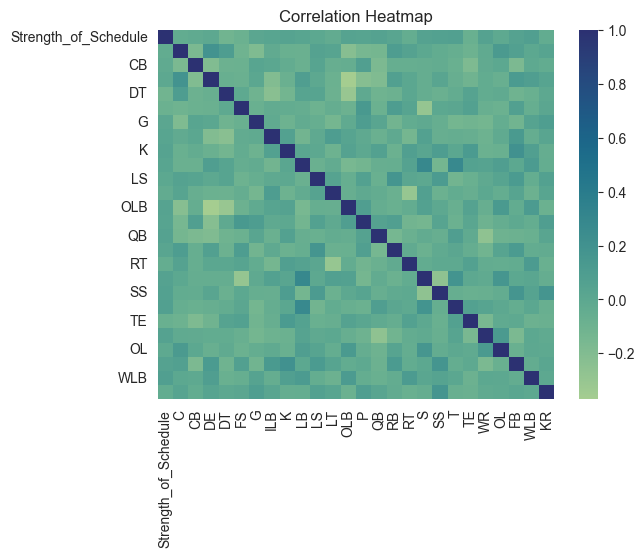

In [3]:
#The analysis seeks to predict win-loss records based on team spending. Certain variables collected, such as 
#points_for and points_allowed will naturally correlated with win_loss record. As such, when considering the full set
#of independent variables, I use only strength of schedule (as win-loss is dependent on how good the opposing teams are)
#and the positional spending data.

#create pairwise correlation matrix from these columns to check for correlation
#.corr() method defaults to the pearson correlation method, which gives the standard correlation coefficient
ind_vars = ['Strength_of_Schedule','C','CB','DE','DT','FS','G','ILB','K','LB',
            'LS','LT','OLB','P','QB','RB','RT','S','SS','T','TE','WR','OL','FB','WLB','KR']
corr = cleaned_data[ind_vars].corr()

#plot a heatmap of the correlation matrix
plt.figure()
plt.title('Correlation Heatmap')
sns.heatmap(corr, cmap = 'crest')
plt.show()

In [4]:
games_missed_cutoff = 4

x_vars = ind_vars.copy()
x_vars.append('O_Line')
X = cleaned_data[x_vars]
X['QB_Lost'] = (cleaned_data['Games_Missed'] > games_missed_cutoff).astype('int')
y = cleaned_data['Win_Loss']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)
train = pd.concat([X_train, y_train], axis = 1)
test = pd.concat([X_test, y_test], axis = 1)

/var/folders/yf/j11_7vd562d42yqbbkd37__00000gn/T/ipykernel_47553/545150431.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['QB_Lost'] = (cleaned_data['Games_Missed'] > games_missed_cutoff).astype('int')


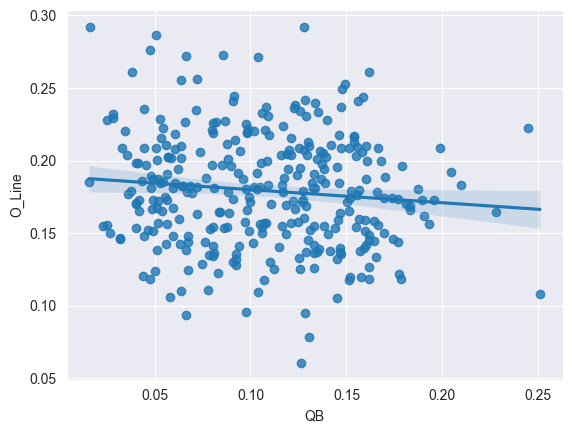

In [5]:
#plot a scatterplot of QB spending vs O-line spending
plt.figure()
sns.regplot(x = 'QB', y = 'O_Line', data = cleaned_data)
plt.show()

In [6]:
#create a linear model of o-line spending as a function of qb spending

qb_v_oline_model = ols('O_Line ~ QB', data = train).fit()

rsquared = qb_v_oline_model.rsquared
rse = np.sqrt(qb_v_oline_model.mse_resid)
train_mean = np.mean(train['O_Line'])


#use linear model to predict O-line spending from qb spqending
y_pred = qb_v_oline_model.predict(test)

#use residuals to calculate a r-squared value and rse for test group
residuals = test['O_Line'] - y_pred
test_mean = np.mean(test['O_Line'])
dist_mean = test['O_Line'] - test_mean
test_rsquared = 1 - np.sum(residuals**2)/np.sum(dist_mean**2)
test_rse = np.std(residuals)

print('R squared value of the linear model: {0:.3f}.'.format(rsquared))
print('Residual standard error of the linear model: {0:.3f}.'.format(rse))
print('The RSE of the linear model is {0:.3f}% of the mean.'.format(rse/train_mean*100))
print('\nR squared value of the linear model applied to the test data: {0:.3f}.'.format(test_rsquared))
print('Residual standard error of the linear model applied to the test data: {0:.3f}.'.format(test_rse))
print('The RSE of the linear model applied to the test data is {0:.3f}% of the mean.'.format(test_rse/test_mean*100))

display(qb_v_oline_model.summary())

R squared value of the linear model: 0.010.
Residual standard error of the linear model: 0.040.
The RSE of the linear model is 22.469% of the mean.

R squared value of the linear model applied to the test data: -0.055.
Residual standard error of the linear model applied to the test data: 0.035.
The RSE of the linear model applied to the test data is 18.503% of the mean.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 O_Line   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.603
Date:                Thu, 31 Oct 2024   Prob (F-statistic):              0.108
Time:                        15:12:37   Log-Likelihood:                 459.06
No. Observations:                 254   AIC:                            -914.1
Df Residuals:                     252   BIC:                            -907.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1869      0.006     29.339      0.000       0.174       0.199
QB            -0.0872      0.054     -1.613      0.108      -0.194       0.019
==============================================================================
Omnibus:                        1.836   Durbin-Watson:                   2.022
Prob(Omnibus):                  0.399   Jarque-Bera (JB):                1.767
Skew:                           0.204   Prob(JB):                        0.413
Kurtosis:                       2.971   Cond. No.                         21.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

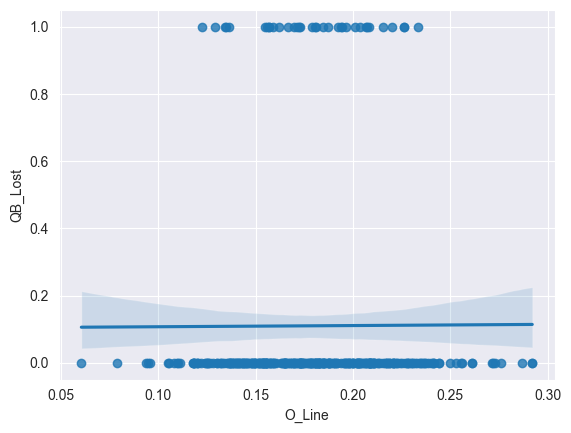

In [7]:
#plot a scatterplot of QB spending vs O-line spending
plt.figure()
sns.regplot(x = 'O_Line', y = 'QB_Lost', data = X, logistic = True)
plt.show()

In [8]:
#create a model to predict if a quarterback will lose significant time due to injury from o-line spending
oline_v_qblost_model = logit('QB_Lost ~ O_Line', data = train).fit()
print(oline_v_qblost_model.summary())

predicted = oline_v_qblost_model.predict(test).astype('int')
cm = confusion_matrix(test['QB_Lost'], predicted)
cm = pd.DataFrame(cm, columns = ['predicted false', 'predicted true'], 
                               index = ['actual false', 'actual true'])
print('\nConfusion Matrix')
display(cm)

Optimization terminated successfully.
         Current function value: 0.355135
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                QB_Lost   No. Observations:                  254
Model:                          Logit   Df Residuals:                      252
Method:                           MLE   Df Model:                            1
Date:                Thu, 31 Oct 2024   Pseudo R-squ.:               4.846e-05
Time:                        15:12:42   Log-Likelihood:                -90.204
converged:                       True   LL-Null:                       -90.209
Covariance Type:            nonrobust   LLR p-value:                    0.9255
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.1309      0.900     -2.366      0.018      -3.896      -0.366
O_Line         0.4618      4.

,predicted false,predicted true
actual false,58,0
actual true,6,0


In [9]:
#function to create a model string to pass into the ols function for given independent/dependent variables
def create_model_string(ind_var, dep_var):
    string = str(dep_var + ' ~ (')
    for var in ind_var:
        string += var + ' + '
    string = string[:-2] #delete last '+'
    string += ') + 0'
    return string

#define all independent and dependent variables to be used for the rest of the analysis
ind_vars = ['Strength_of_Schedule','C','CB','DE','DT','FS','G','ILB','K','LB',
            'LS','LT','OLB','P','QB','RB','RT','S','SS','T','TE','WR','OL','FB','WLB','KR']
dep_var = 'Win_Loss'
    
#create a model using every independent variable
all_var_string = create_model_string(ind_vars, dep_var)
all_var_model = ols(all_var_string, data = train).fit()


rsquared = all_var_model.rsquared
rse = np.sqrt(all_var_model.mse_resid)
train_mean = np.mean(train['Win_Loss'])


#use linear model to predict O-line spending from qb spqending
y_pred = all_var_model.predict(X_test)

#use residuals to calculate a r-squared value and rse for test group
residuals = y_test - y_pred
test_mean = np.mean(test['Win_Loss'])
dist_mean = test['Win_Loss'] - test_mean
test_rsquared = 1 - np.sum(residuals**2)/np.sum(dist_mean**2)
test_rse = np.std(residuals)

print('R squared value of the linear model: {0:.3f}.'.format(rsquared))
print('Residual standard error of the linear model: {0:.3f}.'.format(rse))
print('The RSE of the linear model is {0:.3f}% of the mean.'.format(rse/train_mean*100))
print('\nR squared value of the linear model applied to the test data: {0:.3f}.'.format(test_rsquared))
print('Residual standard error of the linear model applied to the test data: {0:.3f}.'.format(test_rse))
print('The RSE of the linear model applied to the test data is {0:.3f}% of the mean.'.format(test_rse/test_mean*100))

display(all_var_model.summary())

R squared value of the linear model: 0.159.
Residual standard error of the linear model: 0.179.
The RSE of the linear model is 35.437% of the mean.

R squared value of the linear model applied to the test data: -0.434.
Residual standard error of the linear model applied to the test data: 0.240.
The RSE of the linear model applied to the test data is 49.662% of the mean.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Win_Loss   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     1.730
Date:                Thu, 31 Oct 2024   Prob (F-statistic):             0.0201
Time:                        15:12:44   Log-Likelihood:                 90.679
No. Observations:                 254   AIC:                            -129.4
Df Residuals:                     228   BIC:                            -37.39
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Strength_of_Schedule    -0.0227      0.009     -2.653      0.009      -0.040      -0.006
C                        0.8316      0.614      1.353      0.177      -0.379       2.042
CB                      -0.1070      0.277     -0.387      0.699      -0.652       0.438
DE                       0.4576      0.268      1.708      0.089      -0.070       0.985
DT                       0.5457      0.281      1.942      0.053      -0.008       1.099
FS                       1.8359      0.505      3.633      0.000       0.840       2.832
G                       -0.4269      0.409     -1.043      0.298      -1.233       0.380
ILB                      0.6088      0.423      1.441      0.151      -0.224       1.441
K                        1.2088      1.504      0.804      0.422      -1.754       4.172
LB                      -0.0555      1.334     -0.042      0.967      -2.684       2.573
LS                       5.5780      7.228      0.772      0.441      -8.663      19.819
LT                       1.1320      0.436      2.597      0.010       0.273       1.991
OLB                      0.6683      0.277      2.411      0.017       0.122       1.214
P                        3.1239      1.847      1.691      0.092      -0.515       6.763
QB                       0.4795      0.233      2.057      0.041       0.020       0.939
RB                      -0.7855      0.593     -1.326      0.186      -1.953       0.382
RT                       1.2153      0.650      1.870      0.063      -0.065       2.496
S                        0.8372      0.892      0.938      0.349      -0.921       2.595
SS                       0.5341      0.579      0.923      0.357      -0.607       1.675
T                       -0.1214      1.535     -0.079      0.937      -3.147       2.904
TE                       0.5028      0.553      0.909      0.364      -0.587       1.593
WR                       0.4662      0.296      1.573      0.117      -0.118       1.050
OL                       0.3776     29.987      0.013      0.990     -58.709      59.464
FB                       1.1993      1.972      0.608      0.544      -2.686       5.084
WLB                     65.9857     74.451      0.886      0.376     -80.714     212.686
KR                    -498.6576    205.961     -2.421      0.016    -904.487     -92.828
==============================================================================
Omnibus:                        7.398   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                4.235
Skew:                          -0.100   Prob(JB):                        0.120
Kurtosis:                       2.400   Cond. No.                     2.51e+04
==============================================================================

Notes:
[1] Standard Errors 

# Predict on 2024 Data (Current Season)

This section of code will take the salary data from the current season and attempt to predict the end of season records using the trained model from the previous section.

In [224]:
#pull current season record
data2024 = get_yearly_results(2024)

In [225]:
#scrape salary data for 2024 season for each team
position_array = []
error_array = []
for i in range(len(data2024)):
    team = data2024.iloc[i]['Team']
    team = re.sub(' ', '-', team).lower()
    year = str(data2024.iloc[i]['Year'])

    try:

        position_results = get_pos_breakdown(team, year)
        position_array.append([team, year, position_results])

    except:
        print('Scraping error for {0} {1}.'.format(year, team))
        error_array.append([team, year])

In [208]:
#clean scraped data and merge with season records table

#create a set of all possible position labels
position_breakdown = pd.read_csv('position_breakdown.csv')
pos_columns = position_breakdown.columns[:-2]
pos_set = set(pos_columns)
#save all scraped position data to a dataframe, and export to a csv for later use
position_df = pd.DataFrame()
for i in range(len(position_array)):
    pos_dict = position_array[i][2]
    dict_keys = list(pos_dict.keys())
    for p in pos_set:
        if p not in dict_keys:
            pos_dict[p] = 0
    pos_dict['Team'] = position_array[i][0]
    pos_dict['Year'] = position_array[i][1]
    pos_df = pd.DataFrame([pos_dict])
    position_df = pd.concat([pos_df, position_df], ignore_index = True)

position_df = position_df.reset_index(drop = True)

position_df['Team'] = [clean_team_name(team) for team in position_df['Team']]
position_df['Year'] = position_df['Year'].astype('int')

#represent each positional spending as a fraction of the team's total spending for the year
tot_spending = position_df[pos_columns].sum(axis = 1)
position_df['Tot_Spending'] = tot_spending

for col in pos_columns:
    position_df[col] = position_df[col]/position_df['Tot_Spending']

position_df.drop(columns='Tot_Spending',inplace = True)


all_data2024 = pd.merge(data2024, position_df, on = ['Team', 'Year'], how = 'left')

all_data2024.reset_index(drop = True, inplace = True)

#sum of all positions on the offensive line
o_line = ['C','G','LT','RT','T','OL']
all_data2024['O_Line'] = all_data2024[o_line].sum(axis = 1)

all_data2024.to_csv('all_data2024.csv')

all_data2024.head()

,Team,Win,Loss,Tie,Win_Loss,Points_For,Points_Allowed,Point_Differential,Margin_of_Victory,Strength_of_Schedule,SRS,Off_SRS,Def_SRS,Year,C,CB,DE,DT,FB,FS,G,ILB,K,LB,LS,LT,OL,OLB,P,QB,RB,RT,S,SS,T,TE,WR,KR,WLB,O_Line
0,Buffalo Bills,5,2,0,0.714,199,136,63,9.0,-3.2,5.8,4.4,1.4,2024,0.036474,0.105218,0.100030,0.080101,0.008771,0.007858,0.041920,0.015237,0.017956,0.000000,0.004764,0.055518,0.0,0.080221,0.008116,0.130838,0.021550,0.011131,0.034424,0.014579,0.002038,0.047225,0.176031,0.0,0.000000,0.147081
1,Miami Dolphins,2,4,0,0.333,70,129,-59,-9.8,-4.6,-14.4,-14.2,-0.2,2024,0.031809,0.160101,0.081460,0.015943,0.013279,0.018203,0.025345,0.069049,0.019118,0.001025,0.007011,0.051255,0.0,0.139730,0.007106,0.058706,0.034984,0.032230,0.031684,0.000000,0.001269,0.028728,0.171964,0.0,0.000000,0.141908
2,New York Jets,2,5,0,0.286,128,145,-17,-2.4,2.2,-0.2,-2.2,1.9,2024,0.016377,0.134590,0.104046,0.121592,0.000427,0.003843,0.087698,0.033568,0.007332,0.000149,0.005385,0.044185,0.0,0.060181,0.007971,0.113700,0.023333,0.025706,0.018743,0.012832,0.001686,0.058980,0.117675,0.0,0.000000,0.175653
3,New England Patriots,1,6,0,0.143,99,175,-76,-10.9,-3.2,-14.0,-10.7,-3.4,2024,0.040074,0.102248,0.042341,0.096076,0.000000,0.031963,0.043595,0.054382,0.005729,0.005059,0.007064,0.036820,0.0,0.087956,0.004152,0.077380,0.044859,0.059240,0.049595,0.032450,0.000938,0.042683,0.135396,0.0,0.000000,0.180667
4,Pittsburgh Steelers,5,2,0,0.714,161,101,60,8.6,-0.3,8.3,1.6,6.7,2024,0.037571,0.067650,0.128513,0.017031,0.000230,0.019479,0.099524,0.076054,0.019147,0.000041,0.004716,0.028517,0.0,0.163365,0.012298,0.056522,0.035199,0.015318,0.010675,0.097553,0.016208,0.028069,0.066221,0.0,0.000101,0.197139


In [16]:
#predict end of season records using linear model
all_data2024 = pd.read_csv('all_data2024.csv')
pred_2024 = all_var_model.predict(all_data2024)
all_data2024['Predicted_Record'] = pred_2024.round(3)
display(all_data2024[['Team', 'Predicted_Record']].sort_values('Predicted_Record', ascending=False).reset_index(drop=True))

,Team,Predicted_Record
0,Seattle Seahawks,0.675
1,Jacksonville Jaguars,0.671
2,Chicago Bears,0.639
3,Miami Dolphins,0.637
4,New England Patriots,0.617
5,Las Vegas Raiders,0.603
6,Washington Commanders,0.600
7,Buffalo Bills,0.589
8,Cincinnati Bengals,0.588
9,Atlanta Falcons,0.576
